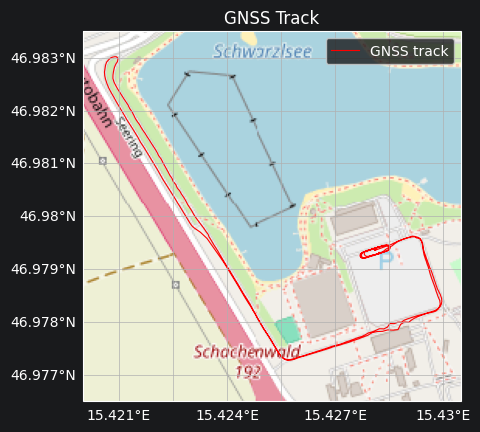

In [1]:
import settings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import importlib
importlib.reload(settings)

def read_gnss():
    raw = open(settings.gnss_file, 'r', encoding='iso-8859-1').readlines()
    gnss_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    gnss_data = np.array(gnss_data)
    return gnss_data

def plot_gnss(gnss_data):
    cimgt_request = cimgt.OSM()
    ax = plt.axes(projection=cimgt_request.crs)
    ax.set_extent(settings.lat_lon_plotting_bounds)
    ax.add_image(cimgt_request, 15)

    plt.plot(gnss_data[:, 2], gnss_data[:, 1], transform=ccrs.PlateCarree(), linewidth=0.8, color='red', label='GNSS track')

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('GNSS Track')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()


gnss_data = read_gnss()
plot_gnss(gnss_data)


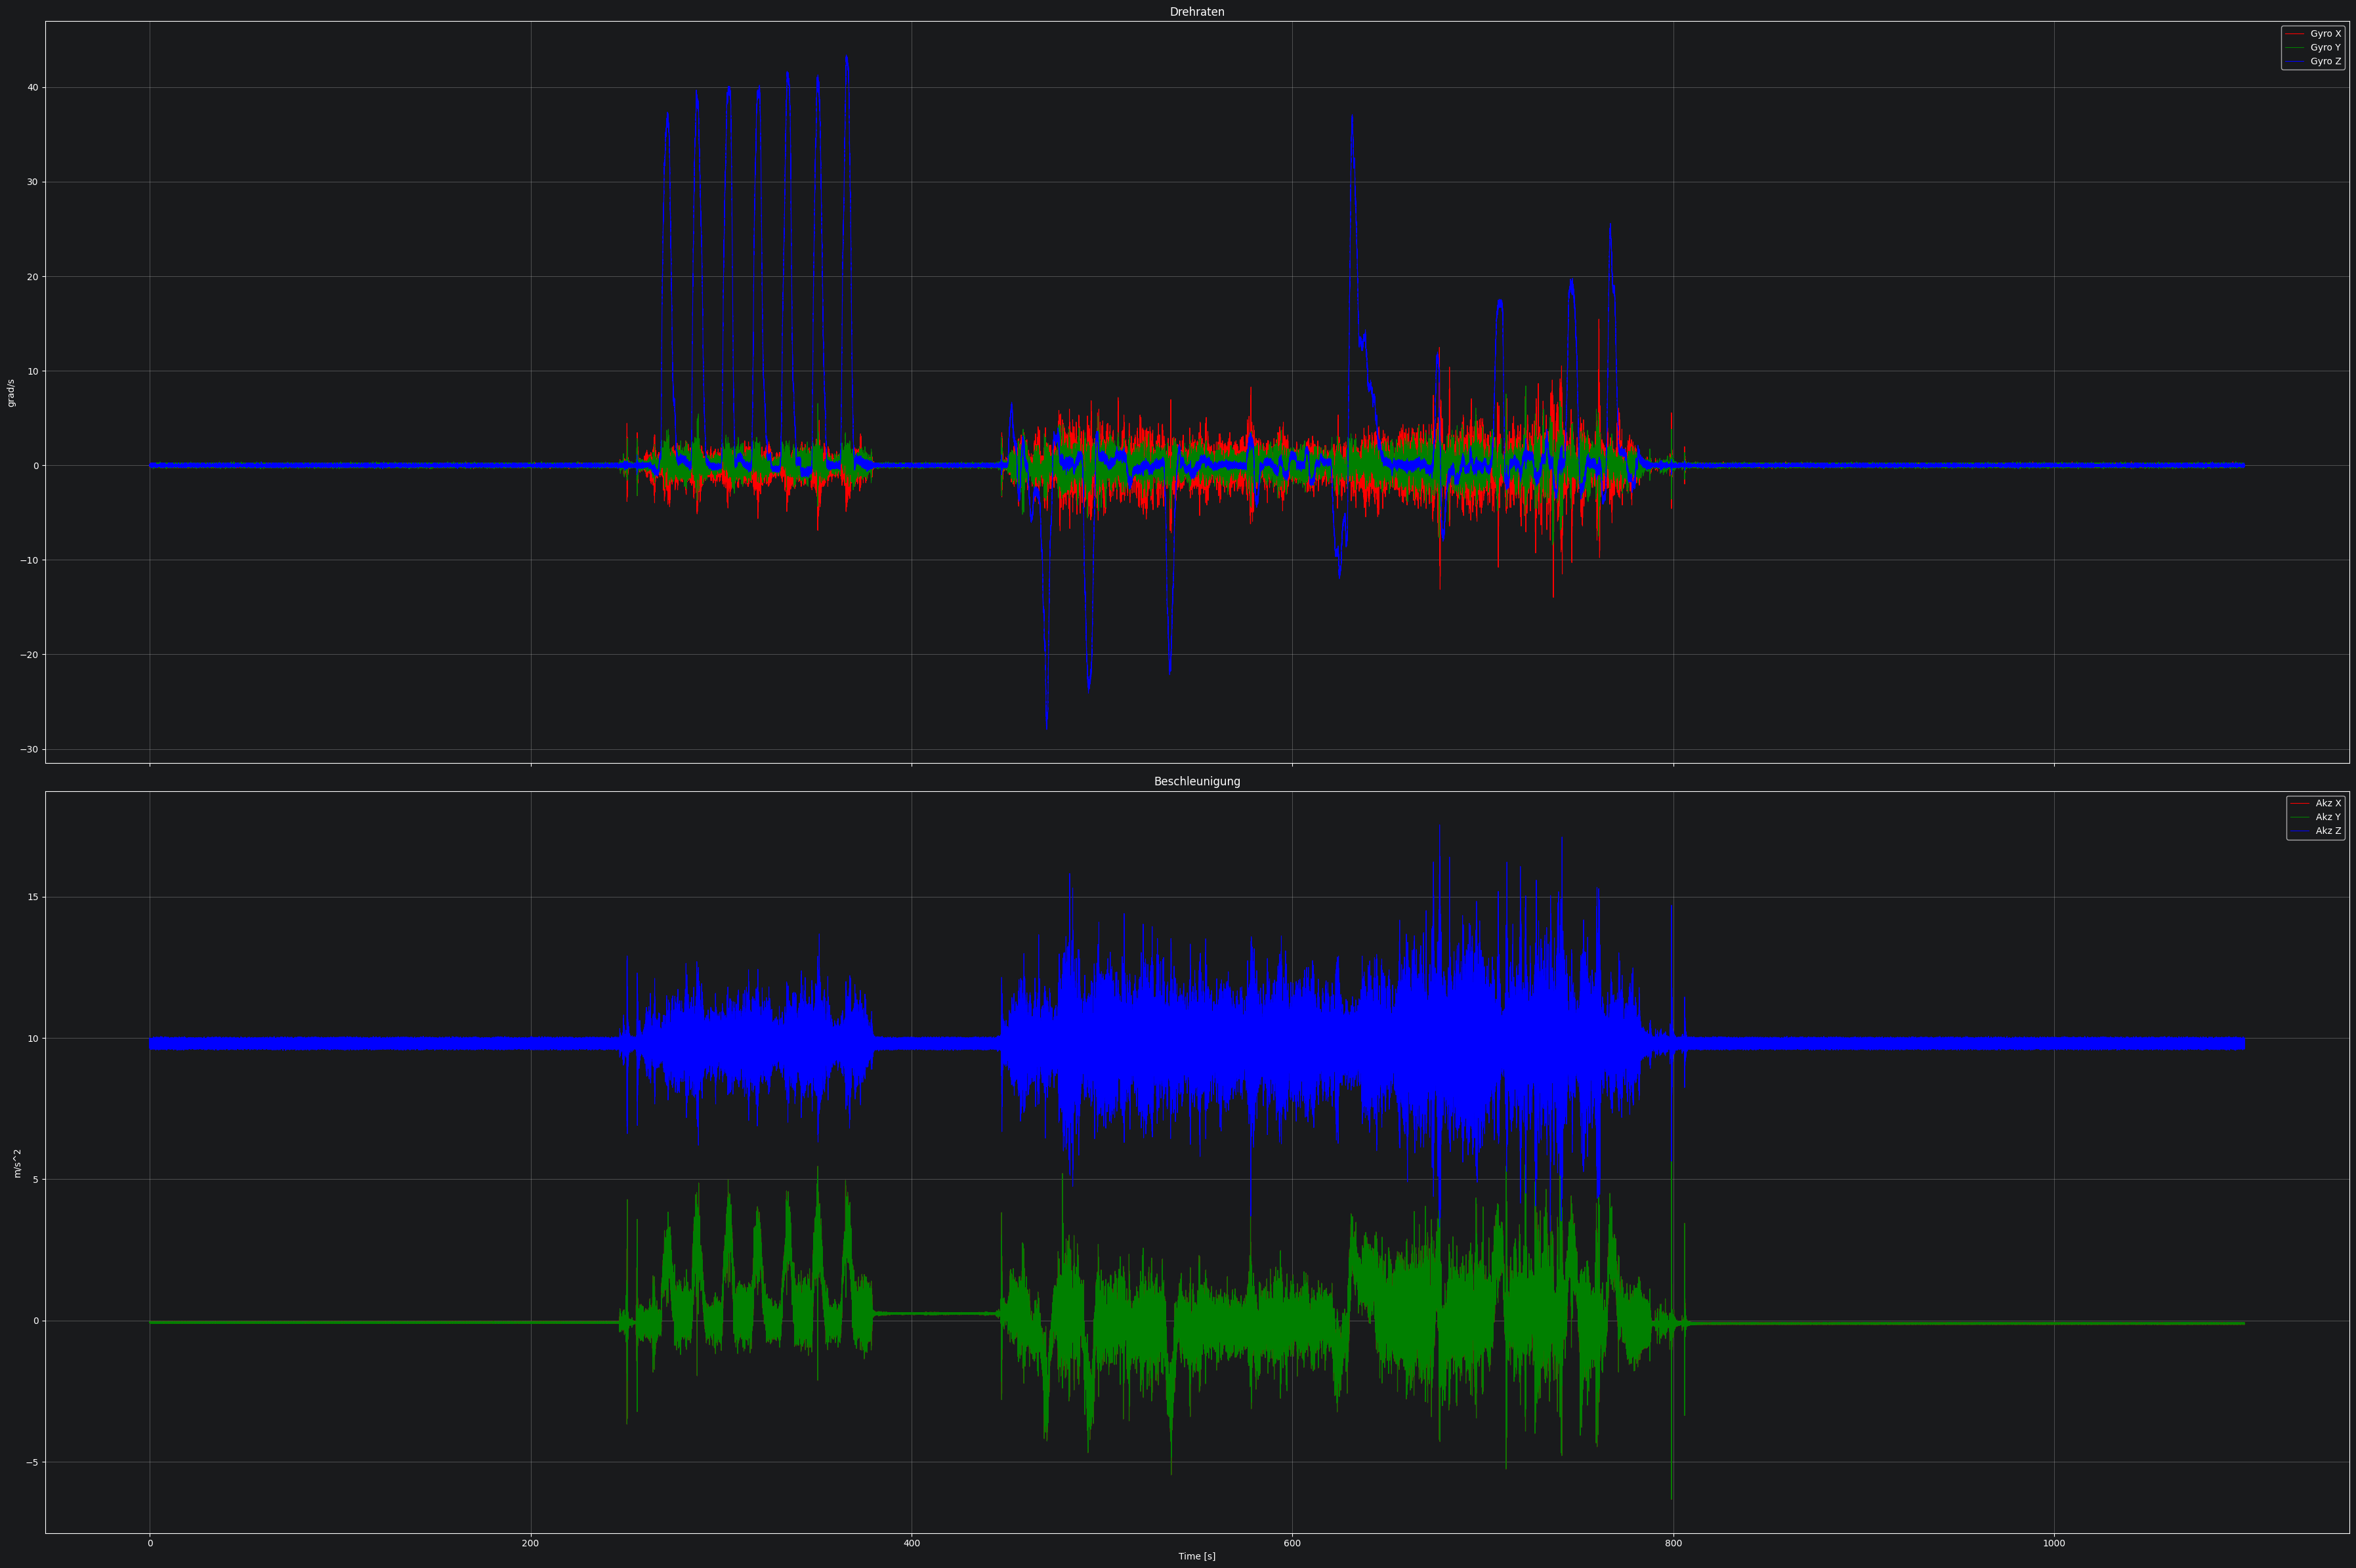

In [2]:

def read_imu():
    raw = open(settings.imu_file, 'r', encoding='iso-8859-1').readlines()
    imu_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    imu_data = np.array(imu_data)
    acc_x = imu_data[:, 5]
    imu_data[:, 5] = -imu_data[:, 4]
    imu_data[:, 4] = acc_x
    return imu_data


def plot_imu(imu_data, still_ranges=[]):
    time = imu_data[:, 0] - imu_data[0, 0]

    fig, axes = plt.subplots(2, 1, figsize=(36, 24), sharex=True)

    axes[0].plot(time, imu_data[:, 1], linewidth=0.8, color='red', label='Gyro X')
    axes[0].plot(time, imu_data[:, 2], linewidth=0.8, color='green', label='Gyro Y')
    axes[0].plot(time, imu_data[:, 3], linewidth=0.8, color='blue', label='Gyro Z')
    axes[0].set_title('Drehraten')
    axes[0].set_ylabel('grad/s')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(time, imu_data[:, 4], linewidth=0.8, color='red', label='Akz X')
    axes[1].plot(time, imu_data[:, 5], linewidth=0.8, color='green', label='Akz Y')
    axes[1].plot(time, imu_data[:, 6], linewidth=0.8, color='blue', label='Akz Z')
    axes[1].set_title('Beschleunigung')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel('m/s^2')
    axes[1].grid(True)
    axes[1].legend()

    for still_range in still_ranges:
        axes[0].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)
        axes[1].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)

    plt.tight_layout()
    plt.show()


imu_b_400hz = read_imu()
plot_imu(imu_b_400hz)


In [3]:
def process_imu(imu_data, window_time, function):
    smooth_indices = int(window_time * settings.imu_hz)
    window = (smooth_indices, 1)
    windows = np.lib.stride_tricks.sliding_window_view(imu_data, window)
    smoothed_imu_data = function(windows, axis=(-2, -1))
    return smoothed_imu_data

def smooth_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.mean)

def max_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.max)

def min_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.min)

imu_b_1hz = smooth_imu(imu_b_400hz, 1.0)
imu_b_5hz = smooth_imu(imu_b_400hz, 0.5)
imu_b_10hz = smooth_imu(imu_b_400hz, 0.1)
imu_b_100hz = smooth_imu(imu_b_400hz, 0.01)

In [4]:
importlib.reload(settings)
def get_still_data(imu_1hz, imu_data):
    imu_max = max_imu(imu_data, 1.0)
    imu_min = min_imu(imu_data, 1.0)
    imu_diff = imu_max - imu_min
    imu_diff[:, 0] = imu_1hz[:, 0]

    still_gyr = np.all(imu_diff[:, 1:4] < settings.still_gyr_threshold, axis=1)
    still_acc = np.all(imu_diff[:, 4:7] < settings.still_acc_threshold, axis=1)
    is_still = np.logical_and(still_gyr, still_acc)

    still_ranges = []
    start_range = None
    for i in range(len(is_still)):
        if is_still[i] and start_range is None:
            start_range = i
        elif (not is_still[i] or i == len(is_still) - 1) and start_range is not None:
            if imu_diff[i, 0] - imu_diff[start_range, 0] >= settings.min_still_time:
                still_ranges.append((start_range, i))
            else:
                print(f'Skipped range {start_range} - {i} because it was too short ({imu_diff[i, 0] - imu_diff[start_range, 0]}s)')
            start_range = None

    return imu_1hz[still_ranges, 0] + np.array([settings.still_time_margin, -settings.still_time_margin])

still_ranges = get_still_data(imu_b_1hz, imu_b_400hz)

Skipped range 100882 - 101773 because it was too short (2.2275267300428823s)
Skipped range 178315 - 178321 because it was too short (0.015000179992057383s)
Skipped range 315417 - 315825 because it was too short (1.0200127575662918s)
Skipped range 316733 - 316744 because it was too short (0.02750033003394492s)
Skipped range 320316 - 321453 because it was too short (2.842535109841265s)


In [5]:
phi_0 = gnss_data[0, 1] / 180.0 * np.pi
lambda_0 = gnss_data[0, 2] / 180.0 * np.pi
h_0 = gnss_data[0, 3]

In [6]:
def gamma(phi):
    return (
        settings.a * settings.gamma_a * np.cos(phi) ** 2 + settings.b * settings.gamma_b * np.sin(phi) ** 2
    ) / np.sqrt(
        settings.a ** 2 * np.cos(phi) ** 2 + settings.b ** 2 * np.sin(phi) ** 2
    )
g_0 = gamma(phi_0)

[ 2.21243292e+05  2.69904662e-03 -9.47693913e-04  3.09040628e-03
 -6.22792121e-02 -6.22792121e-02  9.80542379e+00]


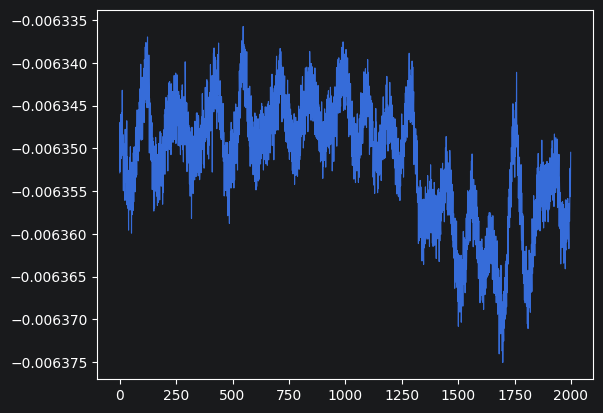

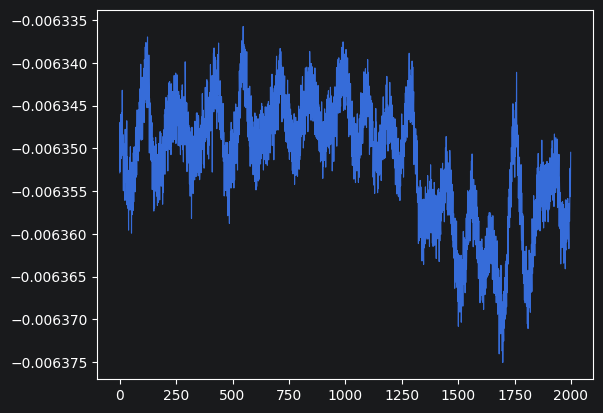

-0.006351420949919304 -0.006351420949919304


(np.float64(-0.006351420949919304), np.float64(-0.006351420949919304))

In [7]:
importlib.reload(settings)

def simple_plot(data):
    fig, ax = plt.subplots()
    ax.plot(data, linewidth=0.8)
    plt.show()

def coarse_alignment(imu_data, range):
    imu_initial = imu_data[np.logical_and(imu_data[:, 0] >= range[0], imu_data[:, 0] <= range[1]), :]
    imu_averaged = np.average(imu_initial, axis=0)
    print(imu_averaged)

    # TODO plot drift of initial data, with selected time range
    pitch = np.atan2(imu_initial[:, 4], imu_initial[:, 6])
    roll = np.atan2(imu_initial[:, 5], imu_initial[:, 6])
    simple_plot(pitch)
    simple_plot(roll)

    pitch_est = np.average(pitch)
    roll_est = np.average(roll)
    print(pitch_est, roll_est)
    return pitch_est, roll_est

coarse_alignment(imu_b_1hz, [still_ranges[0][1] - settings.coarse_alignment_time, still_ranges[0][1]])